# Kaya Decomposition Dashboard Tutorial

This notebook demonstrates how to create Kaya decomposition dashboards using data from the IIASA database.

We'll recreate the figures from the Excel workbook [`vanVuurenIMAGE_15_TOT_19_TFC_current.xlsm`]( https://github.com/zacharyschmidt/kaya-decomposition/blob/main/excel/vanVuurenIMAGE_15_TOT_19_TFC_current.xlsm ):
- **Fig3ExpandKAYAfactorsDEq**: Kaya factors (P, GNP, FE, PEDEq, PEFF, TFC, NFC)
- **Fig4ExpandKAYAratiosDEq**: Kaya ratios (GNP/P, FE/GNP, PEDEq/FE, etc.)
- **Fig6AdditiveDashboard**: Additive dashboard showing contributions to total greenhouse gas emissions by source (NFC, Biomass CCS, Land Use, Industry CO₂, Other Agents).

## The Kaya Identity

The Kaya identity decomposes CO2 emissions into contributing factors:

$$CO_2 = P \times \frac{GDP}{P} \times \frac{FE}{GDP} \times \frac{PE}{FE} \times \frac{PE_{FF}}{PE} \times \frac{TFC}{PE_{FF}} \times \frac{NFC}{TFC}$$

Where:
- **P** = Population
- **GDP/P** = GDP per capita (economic activity per person)
- **FE/GDP** = Energy intensity of the economy
- **PE/FE** = Primary to final energy ratio (energy supply losses)
- **PE_FF/PE** = Fossil fuel fraction of primary energy
- **TFC/PE_FF** = Carbon intensity of fossil energy
- **NFC/TFC** = Net to total carbon ratio (accounts for CCS)

## Setup

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyam

from kaya_decomposition import (
    compute_kaya_variables,
    compute_kaya_factors,
    compute_industrial_process_emissions,
    compute_other_gases_emissions,
    kaya_variables as kv,
    kaya_factors as kf,
    input_variables,
)
from kaya_decomposition.all_sectors import compute_land_use_emissions

warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

## Configuration

Define the scenarios we want to analyze.

In [2]:
# IIASA Database settings
DATABASE = "iamc15"  # IAMC 1.5°C Scenario Explorer
MODEL = "IMAGE 3.0.1"
REF_SCENARIO = "SSP2-Baseline"  # Reference scenario
INT_SCENARIO = "IMA15-TOT"      # Intervention scenario (1.5°C)
REGION = "World"

## Step 1: Download Data from IIASA Database

We'll use `pyam.read_iiasa()` to download scenario data directly from the IAMC 1.5°C Scenario Explorer.

In [3]:
# Required variables for Kaya decomposition
REQUIRED_VARIABLES = [
    "Population",
    "GDP|PPP",
    "GDP|MER",
    "Final Energy",
    "Primary Energy",
    "Primary Energy|Coal",
    "Primary Energy|Oil",
    "Primary Energy|Gas",
    "Emissions|CO2|Energy and Industrial Processes",
    "Emissions|CO2|Industrial Processes",
    "Emissions|CO2|AFOLU",
    "Emissions|CH4",
    "Emissions|N2O",
    "Emissions|F-Gases",
    "Carbon Sequestration|CCS",
    "Carbon Sequestration|CCS|Biomass",
    "Carbon Sequestration|CCS|Fossil|Energy",
    "Carbon Sequestration|CCS|Fossil|Industrial Processes",
    "Carbon Sequestration|CCS|Biomass|Energy",
    "Carbon Sequestration|CCS|Biomass|Industrial Processes",
]

data_for_kaya = pyam.read_iiasa(
    DATABASE,
    model=MODEL,
    scenario=[REF_SCENARIO, INT_SCENARIO],
    region=REGION,
    variable=REQUIRED_VARIABLES,
)

print(f"Downloaded {len(data_for_kaya.data)} data points")
print(f"  Years: {sorted(data_for_kaya.year)}")
print(f"  Variables: {len(data_for_kaya.variable)}")
print(f"  Scenarios: {list(data_for_kaya.scenario)}")

[INFO] 01:21:10 - ixmp4.conf.auth: Connecting to service anonymously and without credentials.
[INFO] 01:21:11 - pyam.iiasa: You are connected to the IXSE_SR15 scenario explorer hosted by IIASA. If you use this data in any published format, please cite the data as provided in the explorer guidelines: https://data.ece.iiasa.ac.at/iamc-1.5c-explorer/#/about
[INFO] 01:21:11 - pyam.iiasa: You are connected as an anonymous user


Downloaded 454 data points
  Years: [2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, 2045, 2050, 2060, 2070, 2080, 2090, 2100]
  Variables: 20
  Scenarios: ['IMA15-TOT', 'SSP2-Baseline']


In [4]:
def prepare_data_for_kaya(df):
    """Prepare IIASA data for Kaya decomposition"""
    data = df.data.copy()
    
    # Fix units (remove $ symbols that cause parsing issues)
    unit_mapping = {
        "billion US$2010/yr": "billion USD_2010/yr",
        "billion US$2005/yr": "billion USD_2005/yr",
    }
    for old_unit, new_unit in unit_mapping.items():
        data.loc[data["unit"] == old_unit, "unit"] = new_unit
    
    # Fill missing CCS variables with zeros
    scenarios = data[["model", "scenario", "region"]].drop_duplicates()
    years = data["year"].unique()
    
    zero_fill_vars = [
        "Carbon Sequestration|CCS",
        "Carbon Sequestration|CCS|Biomass",
        "Carbon Sequestration|CCS|Fossil|Energy",
        "Carbon Sequestration|CCS|Fossil|Industrial Processes",
        "Carbon Sequestration|CCS|Biomass|Energy",
        "Carbon Sequestration|CCS|Biomass|Industrial Processes",
    ]
    
    for _, row in scenarios.iterrows():
        for var in zero_fill_vars:
            existing = data[
                (data["model"] == row["model"])
                & (data["scenario"] == row["scenario"])
                & (data["region"] == row["region"])
                & (data["variable"] == var)
            ]
            if len(existing) == 0:
                new_rows = []
                for year in years:
                    new_rows.append({
                        "model": row["model"],
                        "scenario": row["scenario"],
                        "region": row["region"],
                        "variable": var,
                        "unit": "Mt CO2/yr",
                        "year": year,
                        "value": 0,
                    })
                data = pd.concat([data, pd.DataFrame(new_rows)], ignore_index=True)
    
    return pyam.IamDataFrame(data)

prepared_data = prepare_data_for_kaya(data_for_kaya)

# Add Industrial Processes CO2 emissions data reported directly by study authors
# for the SSP2-Baseline reference case
industrial_processes_data = {
    2005: 1260.644,
    2010: 1619.645,
    2020: 1846.39,
    2030: 2014.855,
    2040: 2097.198,
    2050: 2292.768,
    2060: 2535.193,
    2070: 2635.362,
    2080: 2885.114,
    2090: 3324.232,
    2100: 3714.656,
}

# Get the model name from existing data
model_name = prepared_data.data["model"].iloc[0]
scenario_name = "SSP2-Baseline"
region_name = "World"
variable_name = "Emissions|CO2|Industrial Processes"
unit_name = "Mt CO2/yr"

# Get the underlying pandas DataFrame
data = prepared_data.data.copy()

# Remove existing rows for this variable/scenario/region combination
# to replace with the study authors' reported values
mask = (
    (data["model"] == model_name)
    & (data["scenario"] == scenario_name)
    & (data["region"] == region_name)
    & (data["variable"] == variable_name)
)
data = data[~mask]

# Add new rows with the study authors' reported values
new_rows = []
for year, value in industrial_processes_data.items():
    new_rows.append({
        "model": model_name,
        "scenario": scenario_name,
        "region": region_name,
        "variable": variable_name,
        "unit": unit_name,
        "year": year,
        "value": value,
    })

data = pd.concat([data, pd.DataFrame(new_rows)], ignore_index=True)

prepared_data = pyam.IamDataFrame(data)

In [5]:
# Compute for reference scenario
ref_data = prepared_data.filter(scenario=REF_SCENARIO)
ref_kaya_vars = compute_kaya_variables(ref_data)
ref_kaya_factors = compute_kaya_factors(ref_kaya_vars)

# Compute for intervention scenario
int_data = prepared_data.filter(scenario=INT_SCENARIO)
int_kaya_vars = compute_kaya_variables(int_data)
int_kaya_factors = compute_kaya_factors(int_kaya_vars)

## Step 4: Extract Data for Visualization

In [6]:
def extract_factors(kaya_vars, kaya_factors):
    factors = {}
    
    # Population (billions)
    pop_data = kaya_vars.filter(variable=input_variables.POPULATION).data
    factors["P"] = {int(r["year"]): r["value"] / 1000 for _, r in pop_data.iterrows()}
    
    # GDP (trillions)
    gdp_data = kaya_vars.filter(variable=input_variables.GDP_PPP).data
    factors["GNP"] = {int(r["year"]): r["value"] / 1000 for _, r in gdp_data.iterrows()}
    
    # Final Energy (EJ)
    fe_data = kaya_vars.filter(variable=input_variables.FINAL_ENERGY).data
    factors["FE"] = {int(r["year"]): r["value"] for _, r in fe_data.iterrows()}
    
    # Primary Energy (EJ)
    pe_data = kaya_vars.filter(variable=input_variables.PRIMARY_ENERGY).data
    factors["PEDEq"] = {int(r["year"]): r["value"] for _, r in pe_data.iterrows()}
    
    # Fossil Energy (EJ)
    peff_data = kaya_vars.filter(variable=kv.PRIMARY_ENERGY_FF).data
    factors["PEFF"] = {int(r["year"]): r["value"] for _, r in peff_data.iterrows()}
    
    # Total Fossil Carbon (Gt CO2)
    tfc_data = kaya_vars.filter(variable=kv.TFC).data
    factors["TFC"] = {int(r["year"]): r["value"] / 1000 for _, r in tfc_data.iterrows()}
    
    # Net Fossil Carbon (Gt CO2)
    nfc_data = kaya_vars.filter(variable=kv.NFC).data
    factors["NFC"] = {int(r["year"]): r["value"] / 1000 for _, r in nfc_data.iterrows()}
    
    years = sorted(set.union(*[set(v.keys()) for v in factors.values()]))
    result = pd.DataFrame({"year": years})
    for name, values in factors.items():
        result[name] = result["year"].map(values)
    return result.set_index("year")

def extract_ratios(kaya_factors):
    ratios = {}
    
    data = kaya_factors.filter(variable=kf.GNP_per_P).data
    ratios["GNP/P"] = {int(r["year"]): r["value"] * 1000 for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.FE_per_GNP).data
    ratios["FE/GNP"] = {int(r["year"]): r["value"] * 1000 for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.PEdeq_per_FE).data
    ratios["PEDEq/FE"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.PEFF_per_PEDEq).data
    ratios["PEFF/PEDEq"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.TFC_per_PEFF).data
    ratios["TFC/PEFF"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    data = kaya_factors.filter(variable=kf.NFC_per_TFC).data
    ratios["NFC/TFC"] = {int(r["year"]): r["value"] for _, r in data.iterrows()}
    
    years = sorted(set.union(*[set(v.keys()) for v in ratios.values()]))
    result = pd.DataFrame({"year": years})
    for name, values in ratios.items():
        result[name] = result["year"].map(values)
    return result.set_index("year")

ref_factors = extract_factors(ref_kaya_vars, ref_kaya_factors)
int_factors = extract_factors(int_kaya_vars, int_kaya_factors)
ref_ratios = extract_ratios(ref_kaya_factors)
int_ratios = extract_ratios(int_kaya_factors)

In [7]:
def plot_dashboard(ref_data, int_data, panel_names, panel_labels, title,
                   ncols=4, figsize=(18, 10), ylim_bottom=0):
    """Create a dashboard plot comparing reference and intervention scenarios.

    Parameters:
        ref_data: dict mapping panel names to Series (reference scenario)
        int_data: dict mapping panel names to Series (intervention scenario)
        panel_names: list of panel names to plot
        panel_labels: dict mapping panel names to y-axis labels
        title: main figure title
        ncols: number of columns in grid
        figsize: figure size tuple
        ylim_bottom: bottom y-limit (0 for non-negative, None for auto)
    """
    nrows = (len(panel_names) + ncols - 1) // ncols

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor('#f8f9fa')
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    fig.text(0.5, 0.94, f'Model: {MODEL}  |  Ref: {REF_SCENARIO}  |  Int: {INT_SCENARIO}',
             ha='center', fontsize=11, color='#666')

    gs = fig.add_gridspec(nrows, ncols, hspace=0.35, wspace=0.3, top=0.88, bottom=0.08)

    for i, name in enumerate(panel_names):
        ax = fig.add_subplot(gs[i // ncols, i % ncols])
        ax.set_facecolor('#ffffff')

        ax.plot(ref_data[name].index, ref_data[name].values, color='#1f77b4',
                linewidth=2.5, label='Reference', marker='o', markersize=4)
        ax.plot(int_data[name].index, int_data[name].values, color='#ff7f0e',
                linewidth=2.5, label='Intervention', marker='s', markersize=4)

        ax.set_title(panel_labels[name], fontsize=10, fontweight='bold', pad=10)
        ax.set_xlabel('Year', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(axis='both', labelsize=8)
        ax.set_ylim(ylim_bottom, None)

        if i == 0:
            ax.legend(loc='upper left', fontsize=8)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Hide empty subplots
    for i in range(len(panel_names), nrows * ncols):
        ax = fig.add_subplot(gs[i // ncols, i % ncols])
        ax.axis('off')

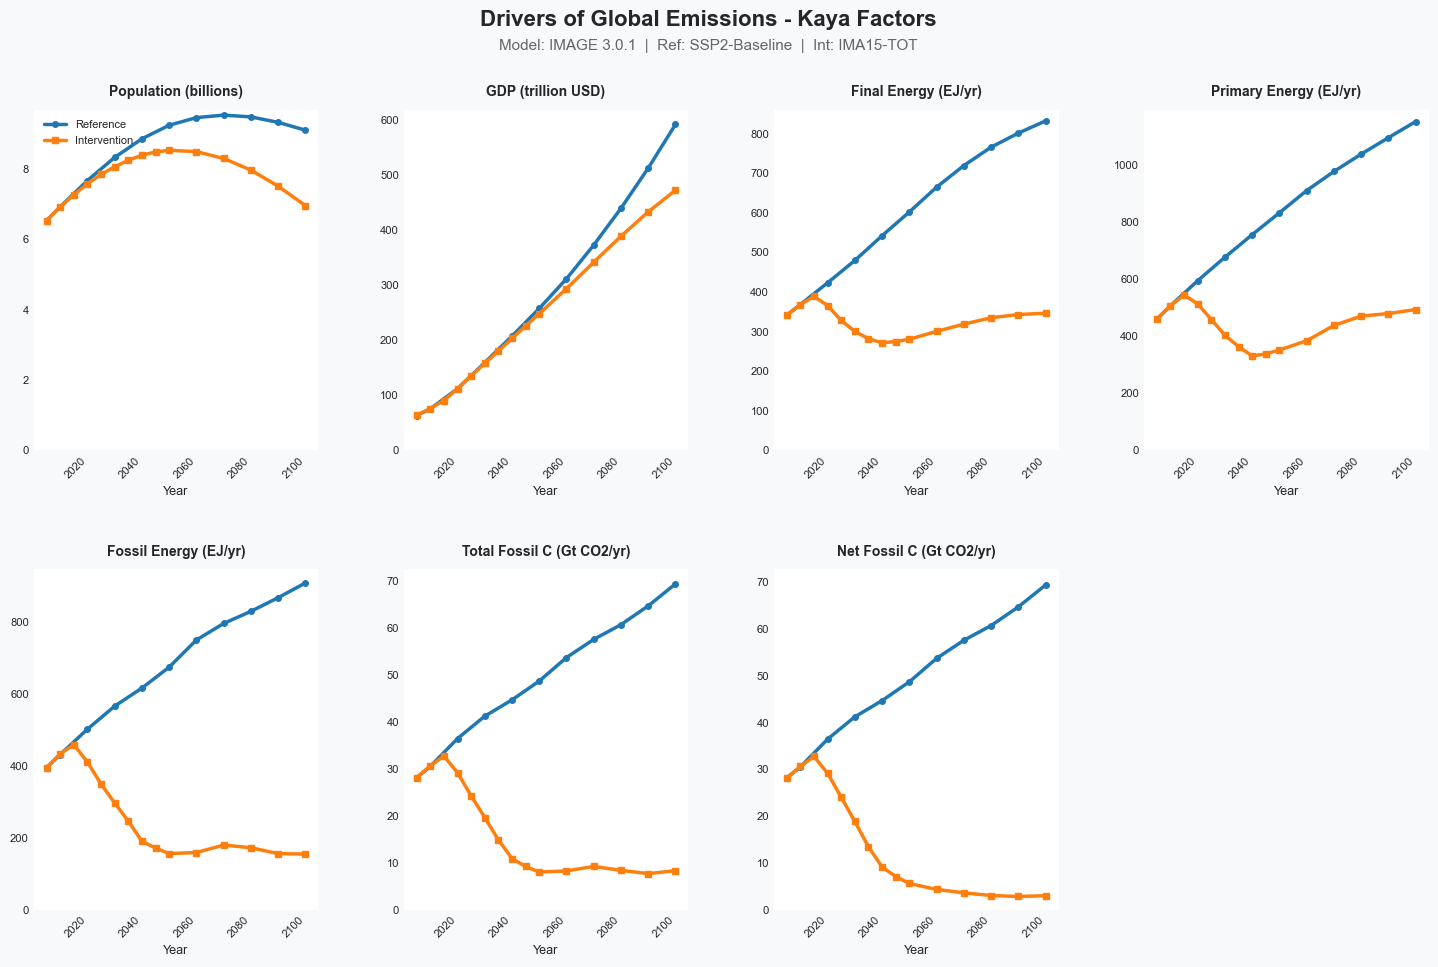

In [8]:
factor_names = ["P", "GNP", "FE", "PEDEq", "PEFF", "TFC", "NFC"]
factor_labels = {
    "P": "Population (billions)",
    "GNP": "GDP (trillion USD)",
    "FE": "Final Energy (EJ/yr)",
    "PEDEq": "Primary Energy (EJ/yr)",
    "PEFF": "Fossil Energy (EJ/yr)",
    "TFC": "Total Fossil C (Gt CO2/yr)",
    "NFC": "Net Fossil C (Gt CO2/yr)",
}

plot_dashboard(
    ref_data={name: ref_factors[name] for name in factor_names},
    int_data={name: int_factors[name] for name in factor_names},
    panel_names=factor_names,
    panel_labels=factor_labels,
    title='Drivers of Global Emissions - Kaya Factors'
)

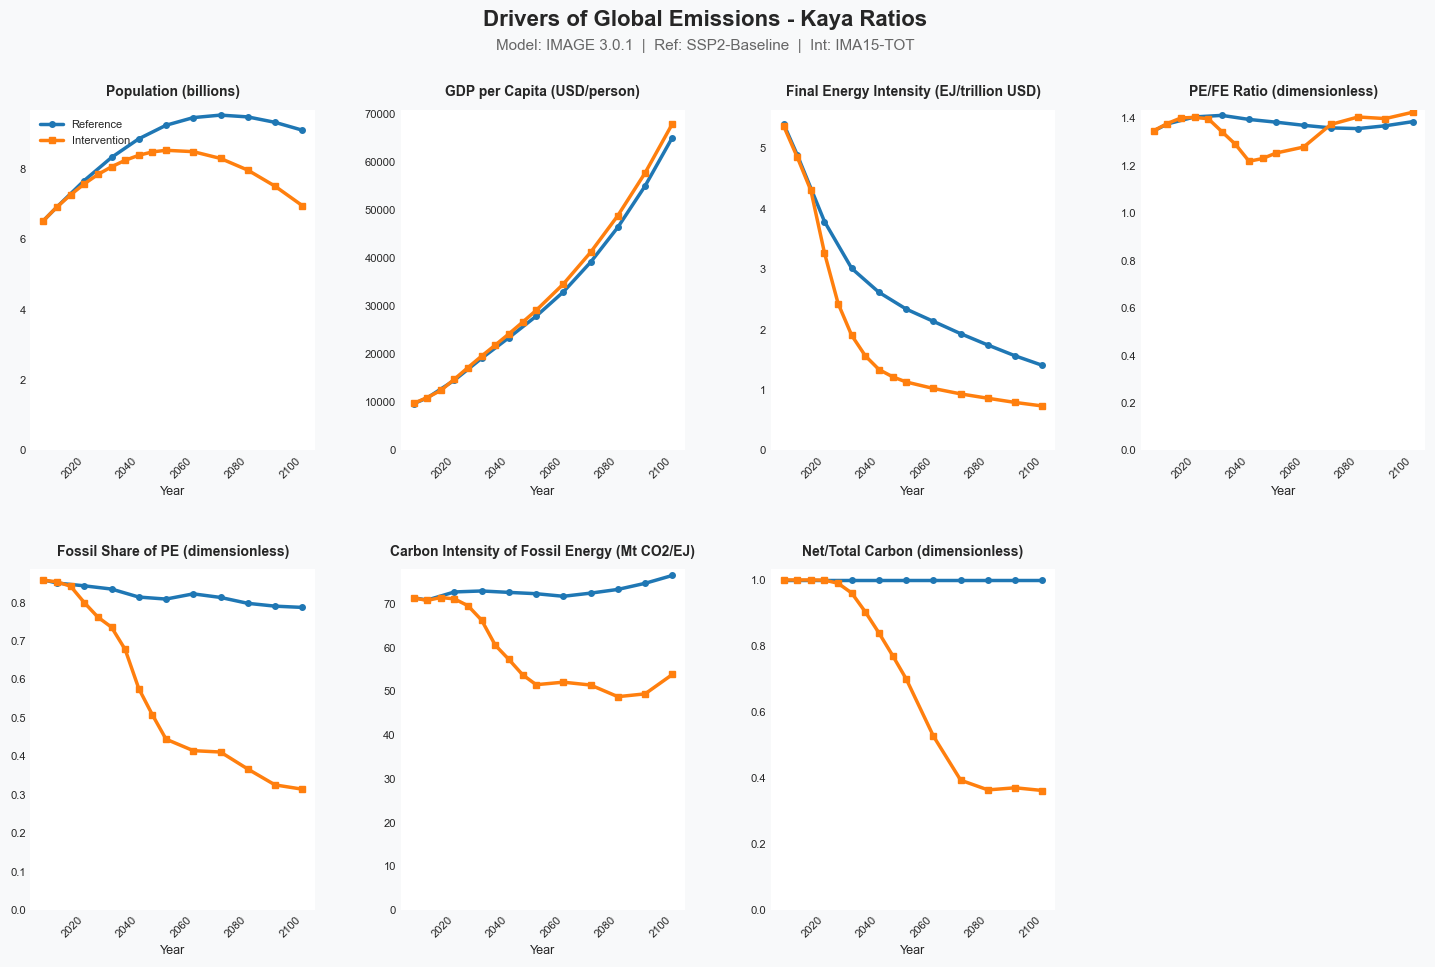

In [9]:
ratio_names = ["P", "GNP/P", "FE/GNP", "PEDEq/FE", "PEFF/PEDEq", "TFC/PEFF", "NFC/TFC"]
ratio_labels = {
    "P": "Population (billions)",
    "GNP/P": "GDP per Capita (USD/person)",
    "FE/GNP": "Final Energy Intensity (EJ/trillion USD)",
    "PEDEq/FE": "PE/FE Ratio (dimensionless)",
    "PEFF/PEDEq": "Fossil Share of PE (dimensionless)",
    "TFC/PEFF": "Carbon Intensity of Fossil Energy (Mt CO2/EJ)",
    "NFC/TFC": "Net/Total Carbon (dimensionless)",
}

# Combine factors and ratios into single dicts
ref_ratio_data = {"P": ref_factors["P"], **{k: ref_ratios[k] for k in ratio_names if k != "P"}}
int_ratio_data = {"P": int_factors["P"], **{k: int_ratios[k] for k in ratio_names if k != "P"}}

plot_dashboard(
    ref_data=ref_ratio_data,
    int_data=int_ratio_data,
    panel_names=ratio_names,
    panel_labels=ratio_labels,
    title='Drivers of Global Emissions - Kaya Ratios'
)

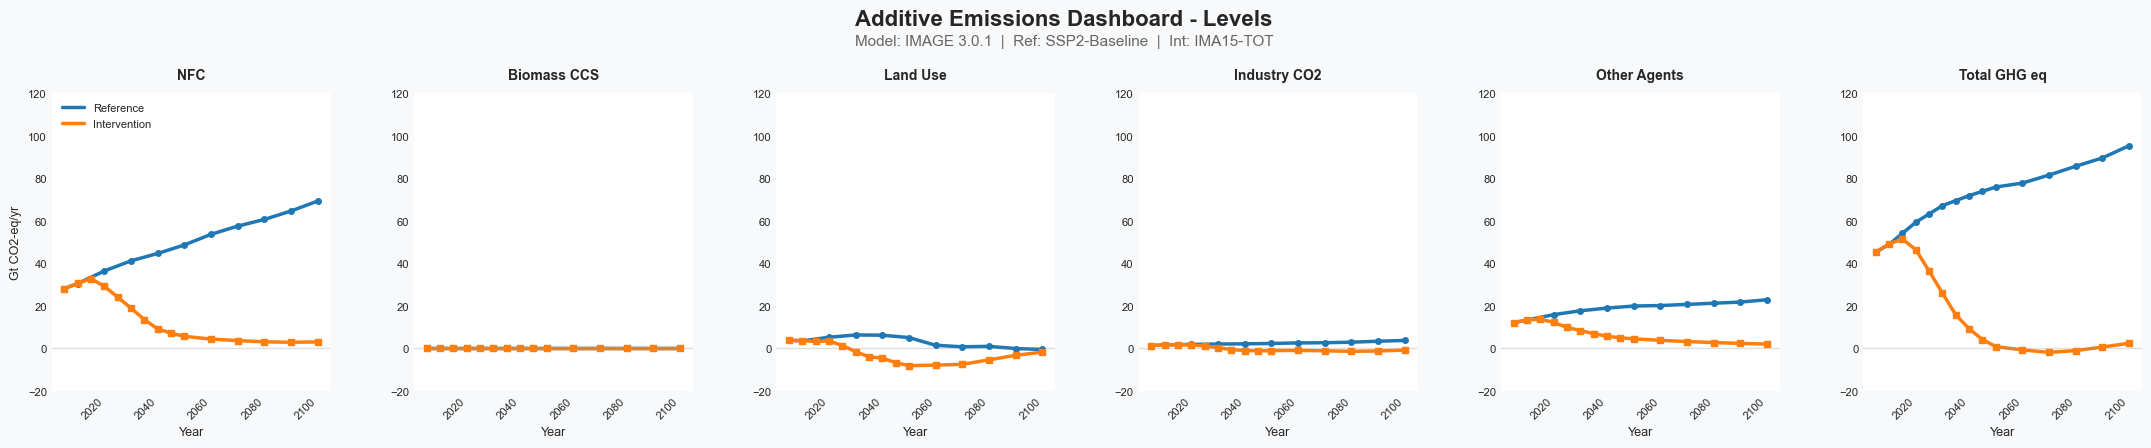

In [ ]:
def extract_additive_data(scenario_data, kaya_vars, is_reference=False):
    nfc = kaya_vars.filter(variable=kv.NFC).data
    # Use missing_value=np.nan to avoid zeros for missing data
    missing_val = np.nan if is_reference else 0.0
    industry = compute_industrial_process_emissions(scenario_data, missing_value=missing_val).data
    other = compute_other_gases_emissions(scenario_data, missing_value=missing_val).data
    land = compute_land_use_emissions(scenario_data).data
    ccs_bio = scenario_data.filter(variable=input_variables.CCS_BIOMASS_ENERGY).data

    def to_series(df, var=None):
        if var:
            df = df[df["variable"] == var]
        return pd.Series(df["value"].values / 1000, index=df["year"].values).sort_index()

    series = {
        "NFC": to_series(nfc),
        "Biomass CCS": to_series(ccs_bio),
        "Land Use": to_series(land, "Emissions|CO2|Land Use"),
        "Industry CO2": to_series(industry, "Net Industrial Carbon"),
        "Other Agents": to_series(other, "Emissions|Other Gases|CO2-equivalent"),
    }
    
    aligned = pd.DataFrame(series).interpolate().ffill().bfill()
    series["Total GHG eq"] = aligned.sum(axis=1)
    return series

ref_additive = extract_additive_data(ref_data, ref_kaya_vars, is_reference=True)
int_additive = extract_additive_data(int_data, int_kaya_vars, is_reference=False)

panel_names = ["NFC", "Biomass CCS", "Land Use", "Industry CO2", "Other Agents", "Total GHG eq"]

fig = plt.figure(figsize=(22, 4.8))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Additive Emissions Dashboard - Levels', fontsize=16, fontweight='bold', y=1.015)
fig.text(0.5, 0.94, f'Model: {MODEL}  |  Ref: {REF_SCENARIO}  |  Int: {INT_SCENARIO}',
         ha='center', fontsize=11, color='#666')

gs = fig.add_gridspec(1, 6, wspace=0.3, top=0.84, bottom=0.22, left=0.04, right=0.99)

for j, key in enumerate(panel_names):
    ax = fig.add_subplot(gs[0, j])
    ax.set_facecolor('#ffffff')
    
    for series, color, label, marker in [(ref_additive[key], '#1f77b4', 'Reference', 'o'),
                                          (int_additive[key], '#ff7f0e', 'Intervention', 's')]:
        if len(series.dropna()) > 1:
            full_range = range(int(series.index.min()), int(series.index.max()) + 1)
            interp = series.reindex(full_range).interpolate().ffill().bfill()
            ax.plot(interp.index, interp.values, color=color, linewidth=2.5, label=label)
            # Scatter only at actual data points
            ax.scatter(series.dropna().index, series.dropna().values, color=color, s=16, marker=marker, zorder=5)

    ax.set_title(key, fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Year', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', labelsize=8)
    ax.axhline(0, color='gray', linewidth=1, alpha=0.25)
    ax.set_ylim(-20, 120)

    if j == 0:
        ax.set_ylabel('Gt CO2-eq/yr', fontsize=9)
        ax.legend(loc='upper left', fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')